# Phase 3: Preprocessing & Augmentation Pipeline

## 1. Objective

This notebook builds the preprocessing pipeline that transforms verified raw data (Phases 1-2) into a form ready for model training — a leakage-free train/validation split, a PyTorch `Dataset` class, and an augmentation strategy — before any modeling begins in Phase 4.

**Starting point:** Phase 2 finalized the training set as `hurricane-harvey` + `hurricane-michael` + `santa-rosa-wildfire`, with `mexico-earthquake` reserved for Phase 7. This phase works exclusively with the 3 confirmed training disasters.

## 2. What This Notebook Covers

1. **3.1** — Train/validation split by location ID (not by file), keeping every location's full file bundle (images, labels, targets, pre/post) together
2. **3.2** — Decision on handling `un-classified` labels for classifier training
3. **3.3** — PyTorch `Dataset` class for lazy loading of image/label pairs
4. **3.4** — Input size decision given hardware constraints
5. **3.5** — Augmentation pipeline design
6. **3.6** — Handling building density variation (from Phase 2.7's finding)
7. **3.7** — Visual verification of a processed batch

## 3.1 Train/Validation Split

**Task:** Split the combined training set (`hurricane-harvey` + `hurricane-michael` + `santa-rosa-wildfire`) into training and validation subsets, split by unique location ID rather than by individual file, so that every file belonging to one location (pre/post images, pre/post labels, pre/post targets) stays together in the same subset.

**Why by location ID, not by file:** each location's 6 related files (images, labels, targets — pre and post) must be treated as one indivisible unit. Splitting file types independently risks a location's pre-image landing in training while its post-image lands in validation, breaking the pairing the model depends on.

**Why only `labels/` was scanned to collect IDs:** Phase 1 already confirmed full parity (equal counts, no mismatches) across `images/`, `labels/`, and `targets/` for all disasters. Since every location's post-disaster label file existence guarantees its matching image and target files also exist, scanning `labels/` alone is sufficient — scanning all three folders would be redundant, since it would only reconfirm a fact already established in Phase 1.

In [ ]:
from pathlib import Path
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append(str(Path("..").resolve()))

DISASTERS = [
    "hurricane-harvey",
    "hurricane-michael",
    "santa-rosa-wildfire"
]

LABELS_DIR = Path("../data/raw/train/labels")

all_location_ids = []
for disaster in DISASTERS:
    pattern = f"*{disaster}*post_disaster.json"
    json_files = LABELS_DIR.glob(pattern)
    
    for file_path in json_files:
        # e.g. "hurricane-harvey_00000042_post_disaster.json" -> "hurricane-harvey_00000042"
        location_id = file_path.stem.replace("_post_disaster", "") # .stem gives filename without extension
        all_location_ids.append(location_id)

train_ids, val_ids = train_test_split(all_location_ids, test_size=0.2, random_state=42)        
print(f"Train: {len(train_ids)} locations, Validation: {len(val_ids)} locations")

# Save the training set and validation set for future uses
with open("../data/processed/train_ids.txt", "w") as f:
    f.write("\n".join(train_ids))

with open("../data/processed/val_ids.txt", "w") as f:
    f.write("\n".join(val_ids))

Train: 710 locations, Validation: 178 locations


### Observations

`all_location_ids` was correctly split into an 80/20 train/validation ratio: **710** training locations and **178** validation locations, from a combined pool across all 3 training disasters.

Only the `labels/` folder was scanned to collect location IDs, since Phase 1 already confirmed that `images/`, `labels/`, and `targets/` share identical IDs (differing only in filename suffix and extension) with full parity across all three. This means any image or target file needed later can be reconstructed directly from an ID using the known naming pattern, rather than needing to load or store full file objects now — keeping this step lightweight (string IDs only) rather than memory-intensive.

Both files were successfully saved to disk for future uses.

## 3.2 Handling `Un-Classified` Labels

**Task:** Decide how to handle the `un-classified` damage label — not a genuine damage severity level, but an annotator's uncertainty marker (Phase 2.5-2.6 found these tend to be smaller, more visually ambiguous buildings) — before training the damage classifier.

**Decision:** Exclude `un-classified` buildings entirely from classifier training data. This project's scope is a 4-class damage severity classifier (No Damage / Minor / Major / Destroyed); `un-classified` doesn't represent a damage level at all, so training on it would ask the model to learn a category outside its intended prediction space. Adding it as a genuine 5th "uncertain" class was considered and rejected — that's a fundamentally different problem (out-of-distribution/uncertainty detection) and would expand this project's scope beyond its defined goal.

In [2]:
from collections import defaultdict
import json 
from shapely.wkt import loads as wkt_loads

def get_area_per_damage_class(disaster_name, labels_dir):
    """Returns the areas for each damage class."""
    pattern = f"*{disaster_name}*post_disaster.json" 
    json_files = labels_dir.glob(pattern)
    area_by_class = defaultdict(list)
    
    for file_path in json_files:
        with open(file_path, "r") as f:
            d = json.load(f)
            for building in d.get("features", {}).get("xy", []):
                wkt_str = building["wkt"]
                subtype = building.get("properties", {}).get("subtype") # damage_class
                if not subtype:
                    subtype = "un-classified"
                polygon = wkt_loads(wkt_str)
                area_by_class[subtype].append(polygon.area)
                
    return dict(area_by_class)

combined_area_by_class = defaultdict(list)                
for disaster in DISASTERS:
    result = get_area_per_damage_class(disaster, LABELS_DIR)
    for damage_class, areas in result.items():
        combined_area_by_class[damage_class].extend(areas)

for damage_class, areas in combined_area_by_class.items():
    print(f"{damage_class}: {len(areas)} buildings")

# Excluding logic
total_combined = sum(len(v) for v in combined_area_by_class.values())
excluded_count = len(combined_area_by_class["un-classified"])  
excluded_pct = excluded_count / total_combined * 100
print(f"Excluding {excluded_count} un-classified buildings ({excluded_pct:.2f}% of {total_combined} total)")


major-damage: 10203 buildings
minor-damage: 7948 buildings
no-damage: 35296 buildings
un-classified: 574 buildings
destroyed: 4629 buildings
Excluding 574 un-classified buildings (0.98% of 58650 total)


### Observations

Across the combined training set (3 disasters), `un-classified` accounts for only 574 buildings out of 58,650 total (0.98%) — a negligible fraction compared to the 4 real damage classes, which range from 4,629 (`destroyed`) to 35,296 (`no-damage`).

This confirms the exclusion decision costs almost nothing in terms of lost training signal. Even independent of the sample size, `un-classified` was never a genuine damage category the model should predict — it's an artifact of annotator uncertainty rather than a real class in this project's 4-class problem definition (No Damage / Minor / Major / Destroyed). The small percentage simply reinforces that excluding it is low-cost as well as conceptually correct.

**Decision finalized:** `un-classified` buildings are excluded from all classifier training, validation, and evaluation going forward.

## 3.3 PyTorch `SegmentationDataset` Class

**Task:** Build a PyTorch-style `Dataset` class that supplies one training example at a time (a pre-disaster image and its matching building-location mask) for the segmentation model, following PyTorch's standard `__len__` / `__getitem__` contract for lazy, on-demand data loading.

**Design decisions:**
- **Separate classes for segmentation vs. classification.** `SegmentationDataset` (this section) only needs "where are the buildings," not damage information — classification will use its own `ClassificationDataset` in Phase 5, since the two tasks need structurally different data.
- **Pre-disaster images only.** Buildings are intact and cleanly shaped pre-disaster, giving the segmentation model the clearest possible signal for what a building's outline looks like — post-disaster imagery (collapsed structures, smoke, debris) would introduce unnecessary noise for a task that doesn't need damage information at all. This matches the standard xView2 challenge approach of training localization separately from damage classification.
- **`un-classified` exclusion (from Section 3.2) does not apply here.** That decision concerns damage labels, which segmentation targets don't contain — the target masks are purely binary (building present or not), confirmed in this section's verification. The exclusion will be implemented in Phase 5's `ClassificationDataset` instead.

**Placement:** the class lives in `src/segmentation_dataset.py` (reusable pipeline code), not in the notebook itself, matching the project's established `src/` vs. `notebooks/` split. Paths are built relative to the file's own location (`Path(__file__).resolve().parent.parent`) rather than the caller's working directory, so the class remains correctly importable from any future location (e.g. Phase 10's FastAPI app).

In [17]:
from src.segmentation_dataset import SegmentationDataset
    
train_dataset = SegmentationDataset(train_ids, augment=True)
val_dataset = SegmentationDataset(val_ids, augment=False)

image, target = train_dataset[0] # can be checked for val_ids as well
print("Image size:", image.size, "mode:", image.mode)
print("Target size:", target.size, "mode:", target.mode)

image.show()
target_array = np.array(target)
print("Target unique pixel values:", np.unique(target_array))  

Image size: (512, 512) mode: RGB
Target size: (512, 512) mode: L
Target unique pixel values: [0 1]


### Observations

`SegmentationDataset`, applied to both `train_ids` (710 locations) and `val_ids` (178 locations), correctly returns paired examples via indexing (`dataset[0]`). Verification of the first training example confirmed:
- **Image:** 1024×1024, RGB (3-channel color) — a genuine pre-disaster satellite photo showing intact buildings, roads, and vegetation
- **Target mask:** 1024×1024, single-channel grayscale (`"L"` mode), with only two unique pixel values (`0`, `1`) — confirming the mask is a pure binary building-location map, containing no damage-class information

This confirms the target masks are structurally independent of damage labels, validating the decision to build separate `Dataset` classes for segmentation and classification rather than one combined class. `SegmentationDataset` is complete and ready to be used with a PyTorch `DataLoader` in Phase 4, where it will supply batched (image, target) pairs to train the building-localization model.

*(Note: this verification reflects the class's state before Section 3.4's resize to 512×512 and 3.5's augmentation were added. See Section 3.4 for the updated dimensions and verification and 3.5 for augmentation design.)*

## 3.4 Input Size Decision

**Task:** Decide on a target input resolution for the segmentation model, and implement resizing inside `SegmentationDataset`, given the hardware constraints established in Phase 0 (CPU-only, 8GB RAM).

**Why resizing is necessary:** all images are 1024×1024 (confirmed in Phase 2.3). Training a CNN at full resolution on CPU is computationally expensive — early layers process input roughly proportional to pixel count, and segmentation specifically requires a full per-pixel output (one prediction per pixel), making input size an even more significant cost factor than for a simple classifier.

**Decision: resize to 512×512** (a 4x reduction in total pixel count from 1024×1024), rather than a more aggressive downsize like 256×256. This choice is grounded in Phase 2's own findings: median building footprint area was ~900-1,200 sq px (Section 2.2), corresponding to roughly 30-35px per side for a square-ish building at full resolution. At 256×256, the smallest buildings would shrink to just a few pixels, risking detection failure — particularly in the densest images (some containing 300+ buildings, per Section 2.7), where small buildings sit close together and could blur into each other at very low resolution. 512×512 preserves roughly double the spatial detail of 256×256 while still delivering a substantial 4x speed/memory improvement over full resolution.

**Two different resize methods are required, not one:** the image is resized using standard smooth resampling (Lanczos), appropriate for photographic content. The target mask — strictly binary (0 or 1) per pixel — must be resized using nearest-neighbor resampling instead, which selects the nearest original pixel's exact value rather than blending. Smooth resampling on a binary mask would introduce invalid fractional values (e.g. 0.4, 0.6) at building edges, destroying its binary meaning.

In [ ]:
image, target = train_dataset[0] # apply the down sampling
print("Image size:", image.size)
print("Target size:", target.size)

# Verify the down sampling
print("Target unique values after resize:", np.unique(np.array(target)))

Image size: (512, 512)
Target size: (512, 512)
Target unique values after resize: [0 1]


### Observations

Resizing from `1024×1024 to 512×512` was verified successfully: both image and target confirm the new 512×512 size, and critically, the target's unique pixel values remain exactly `[0, 1]` after resizing — confirming nearest-neighbor resampling correctly avoided blending, which would have introduced invalid fractional values (e.g. 0.4, 0.6) and broken the mask's binary meaning.

This resize was necessary given hardware constraints: a CNN's early layers process input roughly proportional to its pixel count, so halving each dimension (1024→512) reduces the total pixel count to a quarter `(1,048,576 → 262,144)`, directly reducing compute and memory load throughout the network — critical for CPU-only training on 8GB RAM. This is compounded by segmentation specifically requiring a full per-pixel output (one prediction per pixel, not a single label), making input size an even more significant factor than it would be for a simple classifier.

## 3.5 Augmentation Pipeline Design

**Task:** Design and implement an augmentation pipeline for training data, applied inside `SegmentationDataset`, to reduce overfitting risk given a modest training set (710 locations) and to make the model robust to natural real-world variance in satellite imagery.

**Why augmentation matters here:** satellite images of the same location, captured across different flights/instruments, naturally vary in orientation (no fixed "up" from orbit), lighting, and exposure. Augmenting training data to mimic this variance teaches the model to generalize rather than memorize specific image orientations or lighting conditions.

**Augmentations selected, and why:**
- **Horizontal and vertical flips** (independent 50% chance each) — a building's identity/damage doesn't depend on which direction the satellite was facing; safe and natural for aerial imagery specifically
- **Random rotation (±15°)** — same reasoning as flips, a moderate range that avoids unrealistic extreme angles
- **Brightness and contrast jitter (0.8-1.2x)** — mimics natural variance in lighting/exposure across different imagery passes

**Critical implementation rules:**
- **Geometric transforms (flips, rotation) are applied identically to both the image and its target mask**, using the same random values for both — otherwise the image and its "answer key" would no longer align
- **Brightness/contrast are applied only to the image, never the target** — a binary mask has no meaningful "brightness" to adjust
- **Rotation uses different interpolation per type**: bilinear for the image (smooth), nearest-neighbor for the target (preserves strict 0/1 values), same principle established in Section 3.4's resize
- **Augmentation only applies to training data** (`augment=True`), never validation (`augment=False`) — validation must reflect realistic, unmodified examples to give an honest performance measurement, reusing the same train-only-fitting discipline applied to imputation in the fraud-risk engine project

**Design choice:** augmentation logic lives inside the same `SegmentationDataset` class (`src/segmentation_dataset.py`), controlled by a new `augment` boolean parameter, rather than a separate class — since it's fundamentally part of how each example is prepared before being returned, not a separate concern.

Are the two augmented versions identical? False


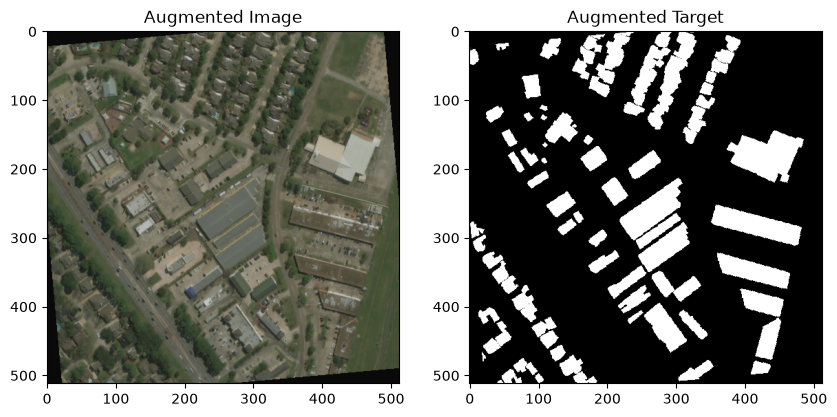

In [27]:
train_dataset = SegmentationDataset(train_ids, augment=True)
val_dataset = SegmentationDataset(val_ids, augment=False)

image1, target1 = train_dataset[5]
image2, target2 = train_dataset[0]

print("Are the two augmented versions identical?", np.array(image1).tolist() == np.array(image2).tolist())

# Visual Proof
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image1)
axes[0].set_title("Augmented Image")
axes[1].imshow(target1, cmap="gray")
axes[1].set_title("Augmented Target")
plt.show()

### Observations

Two independent checks confirm the augmentation pipeline works correctly:

1. **Variation check:** calling `train_dataset[0]` repeatedly produced different pixel values each time (`False` on identity comparison), confirming random augmentations are genuinely applied on each access rather than being silently skipped.

2. **Alignment check (the more important one):** visually plotting an augmented image alongside its augmented target confirmed the two remain correctly aligned after transformation — rotated building clusters in the target mask correspond exactly to the same rotated building locations visible in the image. This directly verifies the critical rule that geometric transforms must be applied identically to both image and target; a variation-only check could not have caught a misalignment bug (e.g. mismatched rotation angles between image and target), so this visual check was necessary, not optional.

`SegmentationDataset` now correctly resizes (Section 3.4) and augments (this section) training examples, while leaving validation examples unmodified — ready for Phase 4's `DataLoader`-based batch training.

## 3.6 Handling Building Density Variation

**Task:** Determine whether the building density variation identified in Section 2.7 (right-skewed distribution, some images containing 300+ buildings; `hurricane-michael` showing a distinctly different, more evenly-spread pattern) requires any change to the preprocessing pipeline built in Sections 3.4-3.5.

**Investigation:** tested the resize (3.4) and augmentation (3.5) logic across multiple random indices, spanning images with varying building counts, checking specifically whether either operation behaves inconsistently or produces artifacts related to density.

**Finding:** neither resize nor augmentation treats dense and sparse images differently — both operations apply uniformly regardless of building count, confirmed directly (consistent 512×512 output across random samples; consistent image-target alignment under augmentation across random samples).

**A separate, more specific concern remains unresolved by these tests:** whether very small buildings in the densest images risk visually merging into a single connected blob after downsampling to 512×512 (each building's already-small footprint, ~30-35px pre-resize, shrinks further to ~15-17px). This was not directly tested here, since it requires inspecting specific known-dense images rather than random sampling.

**Decision: no preprocessing pipeline change at this stage.** This potential merging effect, if it exists, is an inherent tradeoff of the 512×512 resize decision already made and justified in Section 3.4 — not a new problem introduced here, and not something to speculatively "fix" without first confirming it measurably affects model performance. Following the same discipline applied to class imbalance in the fraud-risk engine project, this is acknowledged as a known characteristic of the data rather than acted on prematurely. Its real impact — if any — will be evaluated concretely in Phase 4 (does the model underperform specifically on dense images?) and Phase 6's evaluation, rather than guessed at now.

## 3.7 Visual Verification of the Processed Pipeline

**Task:** As a final check before Phase 4, visually verify the complete preprocessing pipeline (resize + augmentation together, exactly as it will run during real training) across multiple different examples — not just the single examples checked individually in Sections 3.4 and 3.5.

**Why this is a distinct check, not a repeat of 3.4/3.5:** those sections each verified one specific mechanism in isolation (did resize preserve correct sizes/values; did augmentation stay aligned for one example). This section checks whether the finished, combined pipeline consistently produces correct, aligned results across a variety of images — a broader confidence check before trusting the pipeline for actual model training.

**Method:** sampled 5 spread-out indices (`0, 50, 200, 400, 600`) from `train_dataset`, plotting each resulting image alongside its target mask.

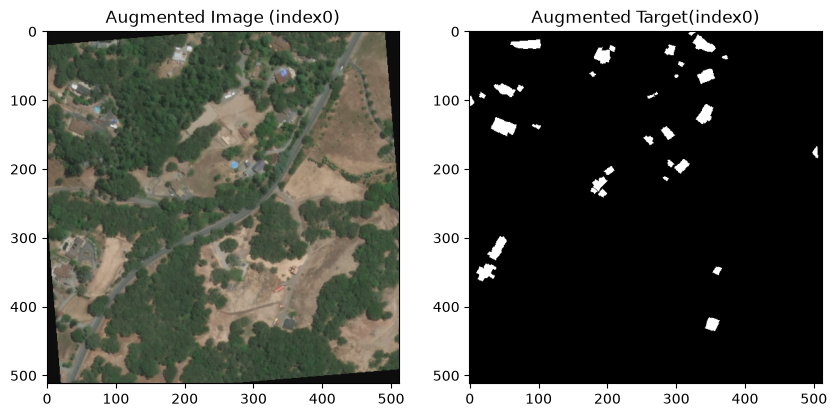

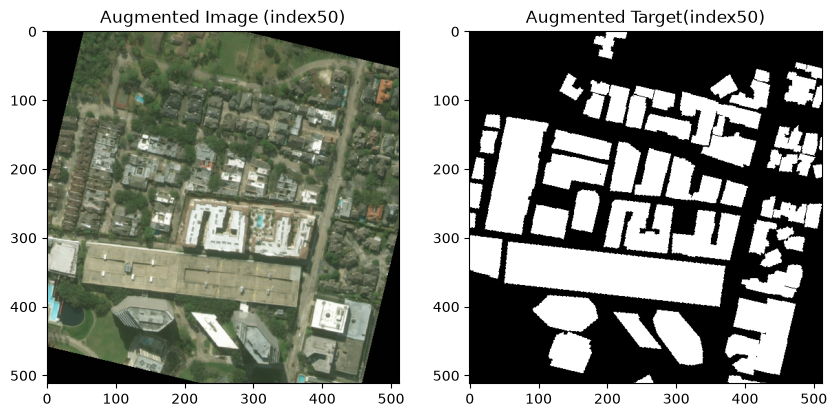

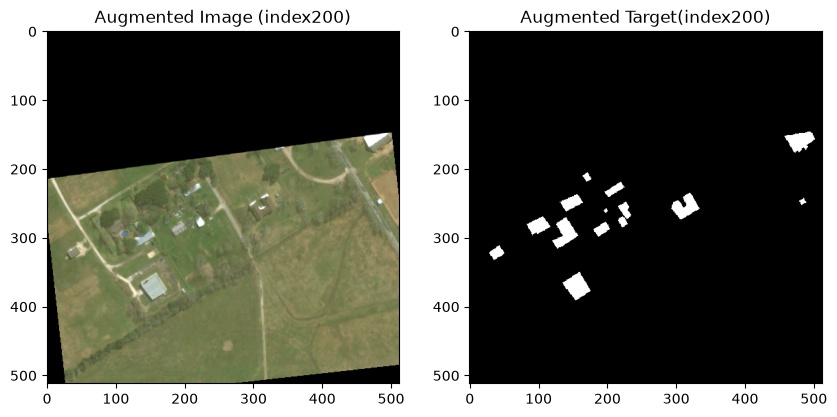

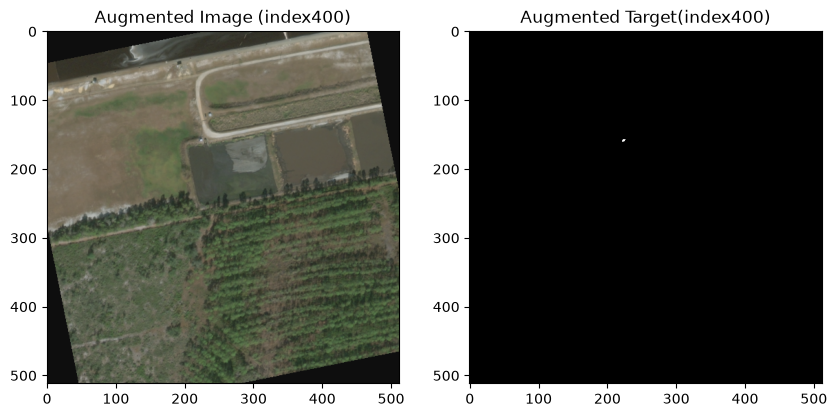

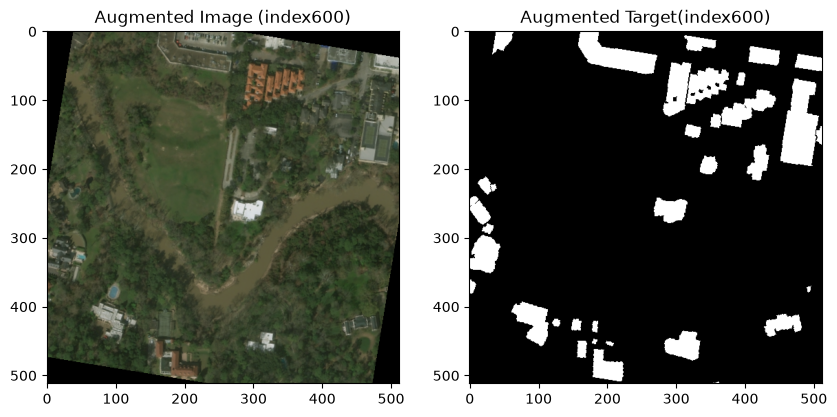

In [34]:
train_dataset = SegmentationDataset(train_ids, augment=True)
indices = [0, 50, 200, 400, 600]

for idx in indices:
    image, target = train_dataset[idx]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image)
    axes[0].set_title(f"Augmented Image (index{idx})")
    axes[1].imshow(target, cmap="gray")
    axes[1].set_title(f"Augmented Target(index{idx})")
    plt.show()

### Observations

All 5 sampled examples showed correctly aligned image-target pairs: building shapes in each target mask corresponded to real building locations in the (variably rotated/flipped/brightness-adjusted) image, with clean, sensible-looking photos and no corruption or artifacts introduced by the combined resize+augmentation pipeline.

This confirms the full `SegmentationDataset` pipeline — loading, resizing to 512×512, and applying augmentation — is working correctly and consistently across a range of examples, not just the single cases checked individually in Sections 3.4 and 3.5. The pipeline is ready for use with a PyTorch `DataLoader` in Phase 4.